In [29]:
!pip install langgraph


In [30]:
!pip install langchain

In [31]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated,Literal

In [32]:
class QuadraticEquation(TypedDict):

  b:int
  a:int
  c:int

  d:float
  equation:str
  result:str


In [33]:
def show_equation(state:QuadraticEquation)->QuadraticEquation:

  equation=f'{state["a"]}x^2{state["b"]}x{state["c"]}'

  return {'equation':equation}


def discriminant(state:QuadraticEquation)->QuadraticEquation:

  d=state["b"]**2 - (4*state["a"]*state["c"])

  return {"d":d}

def real_roots(state:QuadraticEquation)->QuadraticEquation:


  root1=(-state["b"]+(state["d"]**0.5))/(2*state["a"])
  root2=(-state["b"]-(state["d"]**0.5))/(2*state["a"])

  result=f'The roots are{root1} and {root2}'


  return {"result":result}


def one_root(state:QuadraticEquation)->QuadraticEquation:


  root=(-state["b"])/(2*state["a"])


  result=f'The root is {root}'

  return {"result":result}





def no_roots(state:QuadraticEquation)->QuadraticEquation:




  result=f'NO real roots'

  return {"result":result}






In [34]:
def check_condition(state:QuadraticEquation)->Literal["real_roots","no_roots","one_root"]:

  if state["d"]>0:
    return "real_roots"
  
  elif state["d"]==0:
    return "one_root"
  
  else:
    return "no root"

In [35]:
graph=StateGraph(QuadraticEquation)

graph.add_node('show_equation',show_equation)
graph.add_node('discriminant',discriminant)
graph.add_node('real_roots',real_roots)
graph.add_node('one_root',one_root)
graph.add_node('no_roots',no_roots)


graph.add_edge(START,"show_equation")
graph.add_edge("show_equation","discriminant")

graph.add_conditional_edges('discriminant',check_condition)
graph.add_edge('real_roots',END)
graph.add_edge('one_root',END)
graph.add_edge('no_roots',END)


graph.add_edge("discriminant",END)


workflow=graph.compile()

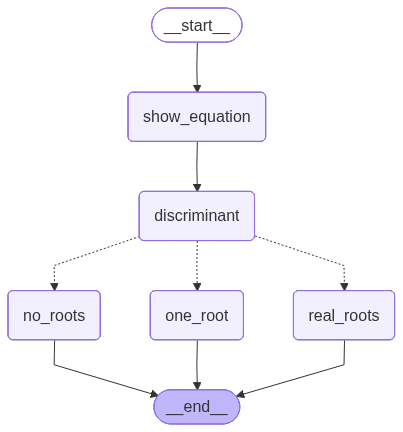

In [36]:
workflow

In [37]:
initial_state={
  "a":4,
  "b":-5,
  "c":-4
}

workflow.invoke(initial_state)

{'b': -5,
 'a': 4,
 'c': -4,
 'd': 89,
 'equation': '4x^2-5x-4',
 'result': 'The roots are1.8042476415070754 and -0.5542476415070754'}